In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

In [2]:
RANDOM_STATE = 42 #semente fixa para usar em todo o modelo
RAW_FILE1 = Path("..") / "data" / "raw" / "application_record.csv"
RAW_FILE2 = Path("..") / "data" / "raw" / "credit_record.csv"
PROCESSED = Path("..") / "data" / "processed"
TARGET = "TARGET"                                            # PREENCHER: variável alvo

pd.set_option("display.max_columns", None)

# Dicionário dos dados

**application_record.csv**

| Feature name | Explanation | Remarks |
| :--- | :--- | :--- |
| ID | Número do cliente |  |
| CODE_GENDER | Gênero |  |
| FLAG_OWN_CAR | Possui carro |  |
| FLAG_OWN_REALTY | Possui imóvel |  |
| CNT_CHILDREN | Número de filhos |  |
| AMT_INCOME_TOTAL | Renda anual |  |
| NAME_INCOME_TYPE | Categoria de renda |  |
| NAME_EDUCATION_TYPE | Nível de escolaridade |  |
| NAME_FAMILY_STATUS | Estado civil |  |
| NAME_HOUSING_TYPE | Tipo de moradia |  |
| DAYS_BIRTH | Data de nascimento | Contagem regressiva a partir do dia atual (0), -1 significa ontem |
| DAYS_EMPLOYED | Data de início do emprego | Contagem regressiva a partir do dia atual (0). Se for positivo, significa que a pessoa está desempregada atualmente. |
| FLAG_MOBIL | Possui celular |  |
| FLAG_WORK_PHONE | Possui telefone do trabalho |  |
| FLAG_PHONE | Possui telefone residencial |  |
| FLAG_EMAIL | Possui e-mail |  |
| OCCUPATION_TYPE | Ocupação / Profissão |  |
| CNT_FAM_MEMBERS | Tamanho da família |  |


**credit_record.csv**

| Feature name | Explanation | Remarks |
| :--- | :--- | :--- |
| ID | Número do cliente |  |
| MONTHS_BALANCE | Mês de registro | O mês dos dados extraídos é o ponto de partida regressivo: 0 é o mês atual, -1 é o mês anterior e assim por diante |
| STATUS | Status | 0: 1-29 dias de atraso <br> 1: 30-59 dias de atraso <br> 2: 60-89 dias de atraso <br> 3: 90-119 dias de atraso <br> 4: 120-149 dias de atraso <br> 5: Dívida vencida, em cobrança ou baixada há mais de 150 dias <br> C: Quitado no mês <br> X: Sem empréstimo no mês |

In [3]:
dados_pessoais = pd.read_csv(RAW_FILE1)
historico_credito = pd.read_csv(RAW_FILE2)

# **1. Visão Geral**

## **1.1 dados_pessoais**

Esta base de dados apresenta o **perfil cadastral** do cliente

In [4]:
dados_pessoais.head(5)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [5]:
dados_pessoais.info()


<class 'pandas.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  str    
 2   FLAG_OWN_CAR         438557 non-null  str    
 3   FLAG_OWN_REALTY      438557 non-null  str    
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  str    
 7   NAME_EDUCATION_TYPE  438557 non-null  str    
 8   NAME_FAMILY_STATUS   438557 non-null  str    
 9   NAME_HOUSING_TYPE    438557 non-null  str    
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL           438557 

A Base de de dados **application_record** possui **438.557** linha e 18 colunas. Sendo 8 delas categóricas.

In [6]:
dados_pessoais.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,438557.0,6.022176e+06,571637.023257,5008804.0,5609375.0,6047745.0,6456971.0,7999952.0
CNT_CHILDREN,438557.0,4.273903e-01,0.724882,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,438557.0,1.875243e+05,110086.853066,26100.0,121500.0,160780.5,225000.0,6750000.0
DAYS_BIRTH,438557.0,-1.599790e+04,4185.030007,-25201.0,-19483.0,-15630.0,-12514.0,-7489.0
DAYS_EMPLOYED,438557.0,6.056368e+04,138767.799647,-17531.0,-3103.0,-1467.0,-371.0,365243.0
FLAG_MOBIL,438557.0,1.000000e+00,0.000000,1.0,1.0,1.0,1.0,1.0
FLAG_WORK_PHONE,438557.0,2.061328e-01,0.404527,0.0,0.0,0.0,0.0,1.0
FLAG_PHONE,438557.0,2.877710e-01,0.452724,0.0,0.0,0.0,1.0,1.0
FLAG_EMAIL,438557.0,1.082071e-01,0.310642,0.0,0.0,0.0,0.0,1.0
CNT_FAM_MEMBERS,438557.0,2.194465e+00,0.897207,1.0,2.0,2.0,3.0,20.0


A coluna `FLAG_MOBIL`não possui variação, todas as linhas são preenchidas com o valor 1. Dessa forma, ela é uma coluna que será removida antes do treinamento do modelo. Por não agregar ao modelo.

In [7]:
mais_novo = (-dados_pessoais['DAYS_BIRTH'].max()/365.25).astype(int)
mais_velho = (-dados_pessoais['DAYS_BIRTH'].min()/365.25).astype(int)
print(f"Mais Novo: {mais_novo} anos" )
print(f"Mais Novo: {mais_velho} anos" )

Mais Novo: 20 anos
Mais Novo: 68 anos


É bem atípico uma pessoa ter 19 filhos, tal informação é um grande candidato a outlier. O cliente mais novo tem, aproximadamente, 20 anos e a mais velha ~69 anos.

In [8]:
dados_pessoais.duplicated().sum()


np.int64(0)

Aparentemente, não há linhas duplicadas.

In [9]:
dados_pessoais.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

A coluna **OCCUPATION_TYPE** (_Ocupação/Profissão_) possui linhas nulas. Totalizando **134203**

### 1.1.1  Explorando a coluna OCCUPATION_TYPE

In [10]:
filtro_nulos = dados_pessoais['OCCUPATION_TYPE'].isnull() #filtro as linhas com o tipo de ocupação nulo
df_nulos = dados_pessoais[filtro_nulos]

In [11]:
df_nulos.head(5)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
7,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0
8,5008813,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0
9,5008814,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0


In [12]:
df_nulos.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,134203.0,6.020344e+06,575717.565351,5008804.0,5581415.5,6047366.0,6461100.5,7999784.0
CNT_CHILDREN,134203.0,2.378263e-01,0.579992,0.0,0.0,0.0,0.0,6.0
AMT_INCOME_TOTAL,134203.0,1.708698e+05,90410.274096,26100.0,112500.0,157500.0,202500.0,1575000.0
DAYS_BIRTH,134203.0,-1.869915e+04,4375.153030,-25201.0,-22216.0,-20368.0,-15183.0,-7773.0
DAYS_EMPLOYED,134203.0,2.038600e+05,182555.623741,-16365.0,-1646.0,365243.0,365243.0,365243.0
FLAG_MOBIL,134203.0,1.000000e+00,0.000000,1.0,1.0,1.0,1.0,1.0
FLAG_WORK_PHONE,134203.0,1.108395e-01,0.313935,0.0,0.0,0.0,0.0,1.0
FLAG_PHONE,134203.0,2.927878e-01,0.455044,0.0,0.0,0.0,1.0,1.0
FLAG_EMAIL,134203.0,8.705469e-02,0.281916,0.0,0.0,0.0,0.0,1.0
CNT_FAM_MEMBERS,134203.0,1.959695e+00,0.778673,1.0,1.0,2.0,2.0,8.0


O que mais chama a atenção é a coluna `DAYS_EMPLOYED`, pois, claramente, há um erro nela. Seu valor máximo é de 365243 dias ou ~1000 anos. É humanamente impossível alguém trabalhar por tanto tempo. Logo, é necessário entender esses valores.

In [13]:
filtro_de = df_nulos['DAYS_EMPLOYED'] == 365243 
df_nulos_filtrado = df_nulos[filtro_de] # dataframe apenas com o tempo empregado de 365243 meses

In [14]:
for col in df_nulos_filtrado.columns:
    print({"Coluna":col,
           "Número de Únicos":df_nulos_filtrado[col].nunique()})

{'Coluna': 'ID', 'Número de Únicos': 75329}
{'Coluna': 'CODE_GENDER', 'Número de Únicos': 2}
{'Coluna': 'FLAG_OWN_CAR', 'Número de Únicos': 2}
{'Coluna': 'FLAG_OWN_REALTY', 'Número de Únicos': 2}
{'Coluna': 'CNT_CHILDREN', 'Número de Únicos': 5}
{'Coluna': 'AMT_INCOME_TOTAL', 'Número de Únicos': 422}
{'Coluna': 'NAME_INCOME_TYPE', 'Número de Únicos': 1}
{'Coluna': 'NAME_EDUCATION_TYPE', 'Número de Únicos': 5}
{'Coluna': 'NAME_FAMILY_STATUS', 'Número de Únicos': 5}
{'Coluna': 'NAME_HOUSING_TYPE', 'Número de Únicos': 6}
{'Coluna': 'DAYS_BIRTH', 'Número de Únicos': 5847}
{'Coluna': 'DAYS_EMPLOYED', 'Número de Únicos': 1}
{'Coluna': 'FLAG_MOBIL', 'Número de Únicos': 1}
{'Coluna': 'FLAG_WORK_PHONE', 'Número de Únicos': 1}
{'Coluna': 'FLAG_PHONE', 'Número de Únicos': 2}
{'Coluna': 'FLAG_EMAIL', 'Número de Únicos': 2}
{'Coluna': 'OCCUPATION_TYPE', 'Número de Únicos': 0}
{'Coluna': 'CNT_FAM_MEMBERS', 'Número de Únicos': 6}


In [15]:
df_nulos_filtrado.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
7,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0
8,5008813,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0
9,5008814,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0
76,5008884,F,N,Y,0,315000.0,Pensioner,Secondary / secondary special,Widow,House / apartment,-20186,365243,1,0,0,0,NaN,1.0
160,5008974,F,N,Y,0,112500.0,Pensioner,Secondary / secondary special,Married,House / apartment,-22319,365243,1,0,0,0,NaN,2.0


Quando se olha para a coluna `NAME_INCOME_TYPE`, ela possui um único valor: `Pensioner`. Logo, todas essas ****75329**** linhas são de aposentados. Diante disso, visando não ter que remover esses dados, já que representam 17,7% da base ****dados_pessoais****, no ****notebook 02-preprocessamento****, somente para essas linhas, a coluna `DAYS_EMPLOYED` será convertida para o valor 0.

# **1.2 historico_credito**
 
 Já esta base é composta pelo **histórico mensal de pagamentos** baseano na coluna **STATUS**

In [16]:
historico_credito.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [17]:
historico_credito.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype
---  ------          --------------    -----
 0   ID              1048575 non-null  int64
 1   MONTHS_BALANCE  1048575 non-null  int64
 2   STATUS          1048575 non-null  str  
dtypes: int64(2), str(1)
memory usage: 24.0 MB


In [18]:
(historico_credito.shape[0]/dados_pessoais.shape[0])

2.3909662826040856

A base **credit.records** possui mais de 2x a quantidade de linhas comparado a base **application.record**. Isso ocorre porque os ID se repetem, proporcionalmente, a quantidade de observações mensais de pagamento.

In [19]:
historico_credito.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,1048575.0,5.068286e+06,46150.578505,5001711.0,5023644.0,5062104.0,5113856.0,5150487.0
MONTHS_BALANCE,1048575.0,-1.913700e+01,14.023498,-60.0,-29.0,-17.0,-7.0,0.0


A obsevação mais antiga de pagamento é datada de 60 meses atrás (-60)

## **1.3 Coluna 'ID'**

A coluna **ID** é extremamente importante pois através dela é possível unir os dois dataframes: **dados_pessoais** e **historico_credito**. 

Todavia, há uma diferença muito grande entre a quantidade de ID únicos, quando comparados os dois.

In [20]:
print(f"Qtd de únicos do dataframe dados_pessoais: {dados_pessoais['ID'].nunique()}")
print(f"Qtd de únicos do dataframe historico_credito: {historico_credito['ID'].nunique()}")

Qtd de únicos do dataframe dados_pessoais: 438510
Qtd de únicos do dataframe historico_credito: 45985


A dataframe **historico_credito** possui um acentuado número de duplicatas porque cada ID repete n vezes o número de observações mensais

In [21]:
ids_dados_pessoais = set(dados_pessoais['ID'])
ids_historico_credito = set(historico_credito['ID'])

print(f"ID's duplicados em dados_pessoais:{dados_pessoais['ID'].duplicated().sum()}")
print(f"ID's duplicados em historico_credito:{historico_credito['ID'].duplicated().sum()}")
print(f"Interseção(ID's que estão em ambas as bases):{len(ids_dados_pessoais & ids_historico_credito)}")

ID's duplicados em dados_pessoais:47
ID's duplicados em historico_credito:1002590
Interseção(ID's que estão em ambas as bases):36457


In [22]:
ids_duplicados_dp  = set(dados_pessoais[dados_pessoais['ID'].duplicated()]['ID']) #filtra os duplicados e quarda-os em um objeto do tipo set
print(f"Quantidade de duplicados com histórico de crédito: {len(ids_duplicados_dp & ids_historico_credito)}")

ids_com_historico = (ids_dados_pessoais & ids_historico_credito)
pct_historico = round((len(ids_com_historico)/len(ids_dados_pessoais)*100),2)
print(f"Clientes com histórico de crédito: {len(ids_com_historico)}\nPorcentagem dos que possuem histórico de crédito: {pct_historico} %")

Quantidade de duplicados com histórico de crédito: 0
Clientes com histórico de crédito: 36457
Porcentagem dos que possuem histórico de crédito: 8.31 %


****Ponderações:****

Há ****47 IDs duplicados**** na base de cadastro; entretanto, nenhum deles possui histórico de crédito. Além disso, quando comparamos a interseção entre os bancos de dados, ou seja, os ****IDs**** que estão em ambas as bases, o escopo real de trabalho cai para apenas ****36.457**** clientes, ****8,31 %**** do cadastro.

Ou seja, como estamos tratando esses dados para utilizá-los em um modelo de machine learning, buscando prever ****bons ou maus**** pagadores, é indispensável que todos os nossos clientes possuam histórico de crédito.


# **2. Distribuição das variáveis**

## **2.1 Base para análise dos dados**

Para uma melhor análise das **variáveis numéricas** e **categóricas** das duas bases de dados: **dados_cadastrais** e **historico_credito** será criado um dataframe **df_plot** com uma junção dos dois dataframes.

**### 2.1.1 Ajustando o dataframe "historico_credito"**

Como identificado anteriormente, a base `historico_credito` armazena o ****status**** de pagamento de cada cliente; por isso, seu número de linhas e IDs é mais inflado. Para que não ocorram repetições quando uni-la à base `dados_pessoais`, é necessário usar a função ****groupby**** para agrupar os dados em torno do ****ID****, aplicando uma função.

As colunas `WORST_STATUS`, `MONTHS_OBS` e `MONTH_BEGAN` são insights retirados das colunas `MONTHS_BALANCE` e `STATUS`.


In [23]:
#criacao de novos dataframes para não modificar a base de dados original.
df_cad = dados_pessoais.copy()
df_cred = historico_credito.copy()

In [24]:
df_cred.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [25]:
#remapeando a variável STATUS de modo que seus valores sejam apenas números

map_status = {'X':-2,'C':-1, '0':0, '1':1, '2':2, '3':3, '4':4, '5':5}
df_cred['STATUS'] = df_cred['STATUS'].map(map_status)

In [26]:
df_cred = df_cred.groupby('ID').agg(
    WORST_STATUS = ('STATUS','max'), # cria uma coluna que guarda a pior faixa de atraso
    MONTHS_OBS = ('MONTHS_BALANCE','count'),#cria uma coluna c/ a quantidade de meses observados
    MONTH_BEGAN = ('MONTHS_BALANCE','min')# cria uma coluna que informa há quantos meses o cliente é observado
).reset_index()

In [27]:
df_cad['AGE_YEARS'] = (-df_cad['DAYS_BIRTH']/365.25).astype(int)  
df_cad['YEARS_EMPLOYED'] = np.where(df_cad['DAYS_EMPLOYED'] > 0, 0, (-df_cad['DAYS_EMPLOYED'])/365.25).astype(int)

In [28]:
base = pd.merge(df_cad,df_cred,how='inner',on='ID')

## 2.2 Variáveis Numéricas

In [29]:
base.head(3)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE_YEARS,YEARS_EMPLOYED,WORST_STATUS,MONTHS_OBS,MONTH_BEGAN
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,32,12,1,16,-15
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,32,12,1,15,-14
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,58,3,0,30,-29


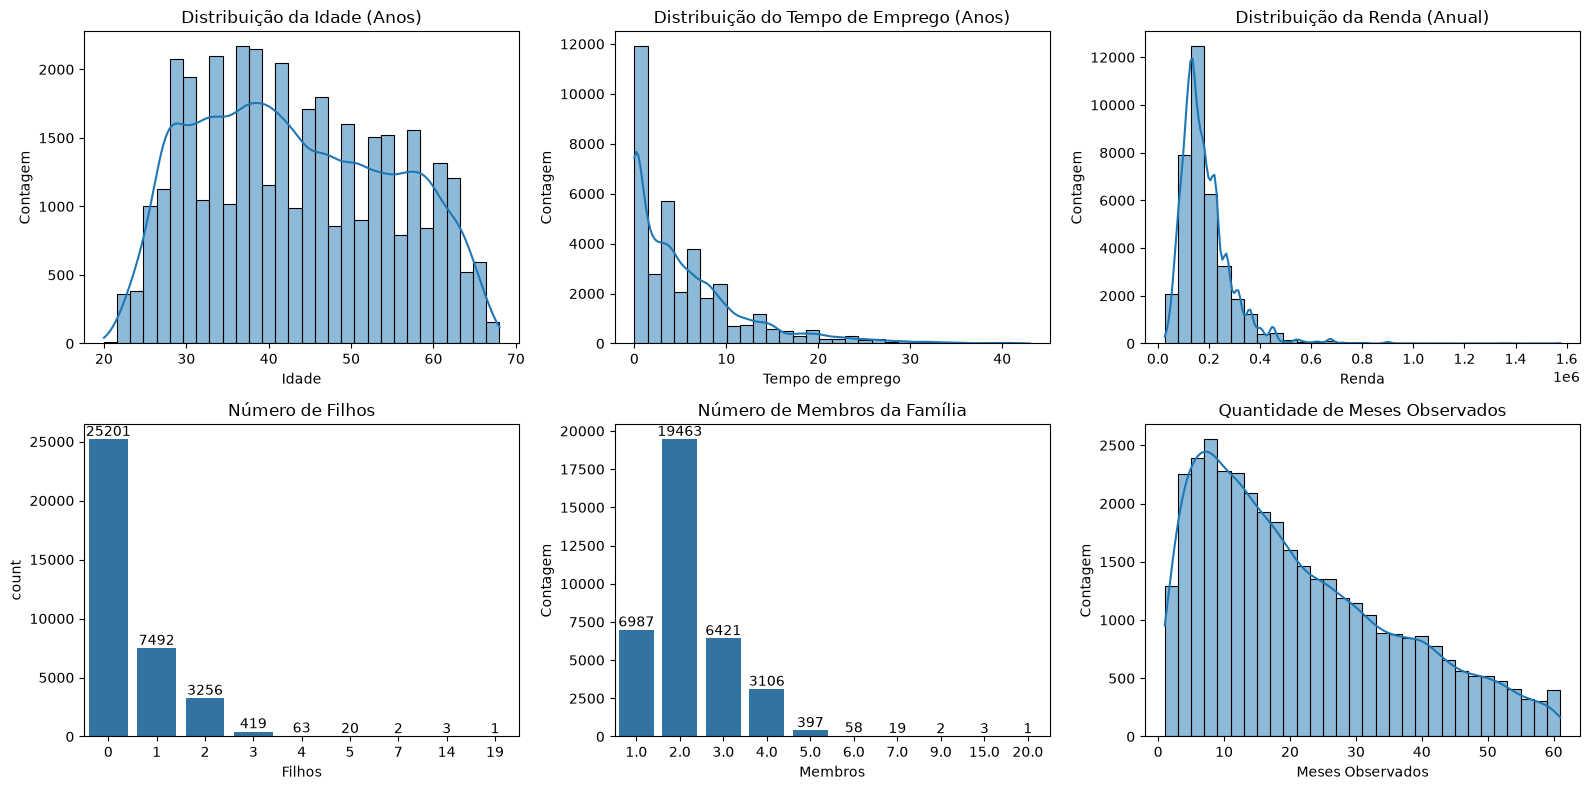

In [30]:
num_cols = ["AGE_YEARS", "YEARS_EMPLOYED", "AMT_INCOME_TOTAL",
            "CNT_CHILDREN", "CNT_FAM_MEMBERS", "MONTHS_OBS"]

fig, axes = plt.subplots(2,3, figsize = (16,8))
#grafico line:1 col:1 
sns.histplot(x = base['AGE_YEARS'],
             bins=30,
             ax = axes[0,0],
             kde = True)
axes[0,0].set(title = ('Distribuição da Idade (Anos)'),
              xlabel = 'Idade',
              ylabel = 'Contagem')
#grafico line:1 col:2 
sns.histplot(x = base['YEARS_EMPLOYED'],
             bins=30,
             ax = axes[0,1],
             kde = True)
axes[0,1].set(title = ('Distribuição do Tempo de Emprego (Anos)'),
              xlabel = 'Tempo de emprego',
              ylabel = 'Contagem')
#grafico line:1 col: 3
sns.histplot(x = base['AMT_INCOME_TOTAL'],
             bins=30,
             ax = axes[0,2],
             kde = True)
axes[0,2].set(title = ('Distribuição da Renda (Anual)'),
              xlabel = 'Renda',
              ylabel = 'Contagem')

#grafico line:2 col: 1
sns.countplot(x = base['CNT_CHILDREN'],
             ax = axes[1,0])
axes[1,0].set(title = ('Número de Filhos'),
              xlabel = 'Filhos',)
#Visualização dos valores em cima das barras
for container in axes[1,0].containers:
    axes[1,0].bar_label(container, padding = 0) #padding distancia entre o valor e a barra

#grafico line:2 col: 2
sns.countplot(x = base['CNT_FAM_MEMBERS'],
             ax = axes[1,1])
axes[1,1].set(title = ('Número de Membros da Família'),
              xlabel = 'Membros',
              ylabel = 'Contagem')
#Visualização dos valores em cima das barras
for container in axes[1,1].containers:
    axes[1,1].bar_label(container, padding = 0) #padding distancia entre o valor e a barra

#grafico line:2 col: 3
sns.histplot(x = base['MONTHS_OBS'],
             ax = axes[1,2],
             bins= 30,
             kde = True)
axes[1,2].set(title = ('Quantidade de Meses Observados'),
              xlabel = 'Meses Observados',
              ylabel = 'Contagem')
#for col in num_cols:
#    sns.histplot(data=)
plt.tight_layout()
plt.show()

In [31]:
base[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
AGE_YEARS,36457.0,43.23,11.50,20.0,34.0,42.0,53.0,68.0
YEARS_EMPLOYED,36457.0,5.61,6.41,0.0,1.0,4.0,8.0,43.0
AMT_INCOME_TOTAL,36457.0,186685.74,101789.23,27000.0,121500.0,157500.0,225000.0,1575000.0
CNT_CHILDREN,36457.0,0.43,0.74,0.0,0.0,0.0,1.0,19.0
CNT_FAM_MEMBERS,36457.0,2.20,0.91,1.0,2.0,2.0,3.0,20.0
MONTHS_OBS,36457.0,21.33,14.91,1.0,9.0,18.0,31.0,61.0


****Interpretações****

* ****1. Idade:**** Não há menores de idade. A idade mínima é de 20 anos e a máxima é de 68 anos. Percebe-se uma concentração entre 25 e 45 anos, com alguns picos nessa faixa. Por fim, a frequência diminui nas idades mais avançadas; entretanto, existe uma quantidade significativa de clientes até cerca de 65 anos.

* ****2. Tempo de emprego:**** Há uma quantidade muito grande de pessoas sem emprego. É necessário uma análise mais minuciosa nesta coluna, principalmente de seus outliers.

* ****3. Renda:**** É visivelmente assimétrica à direita, ou seja, alguns valores altos puxam a média para a direita, tornando-a maior que a mediana.

* ****4. Nº de filhos e membros da família:**** A esmagadora maioria das pessoas não possui filhos: mais de 69% (25201/36457) da população analisada. Além disso, 53% (19463/36457) têm uma família de duas pessoas.

* ****5. Meses observados:**** Também apresenta uma distribuição assimétrica à direita. A quantidade de meses disponível para observação na base é menor para muitos clientes e maior para uma parcela menor.


## 2.3 Variáveis Categóricas

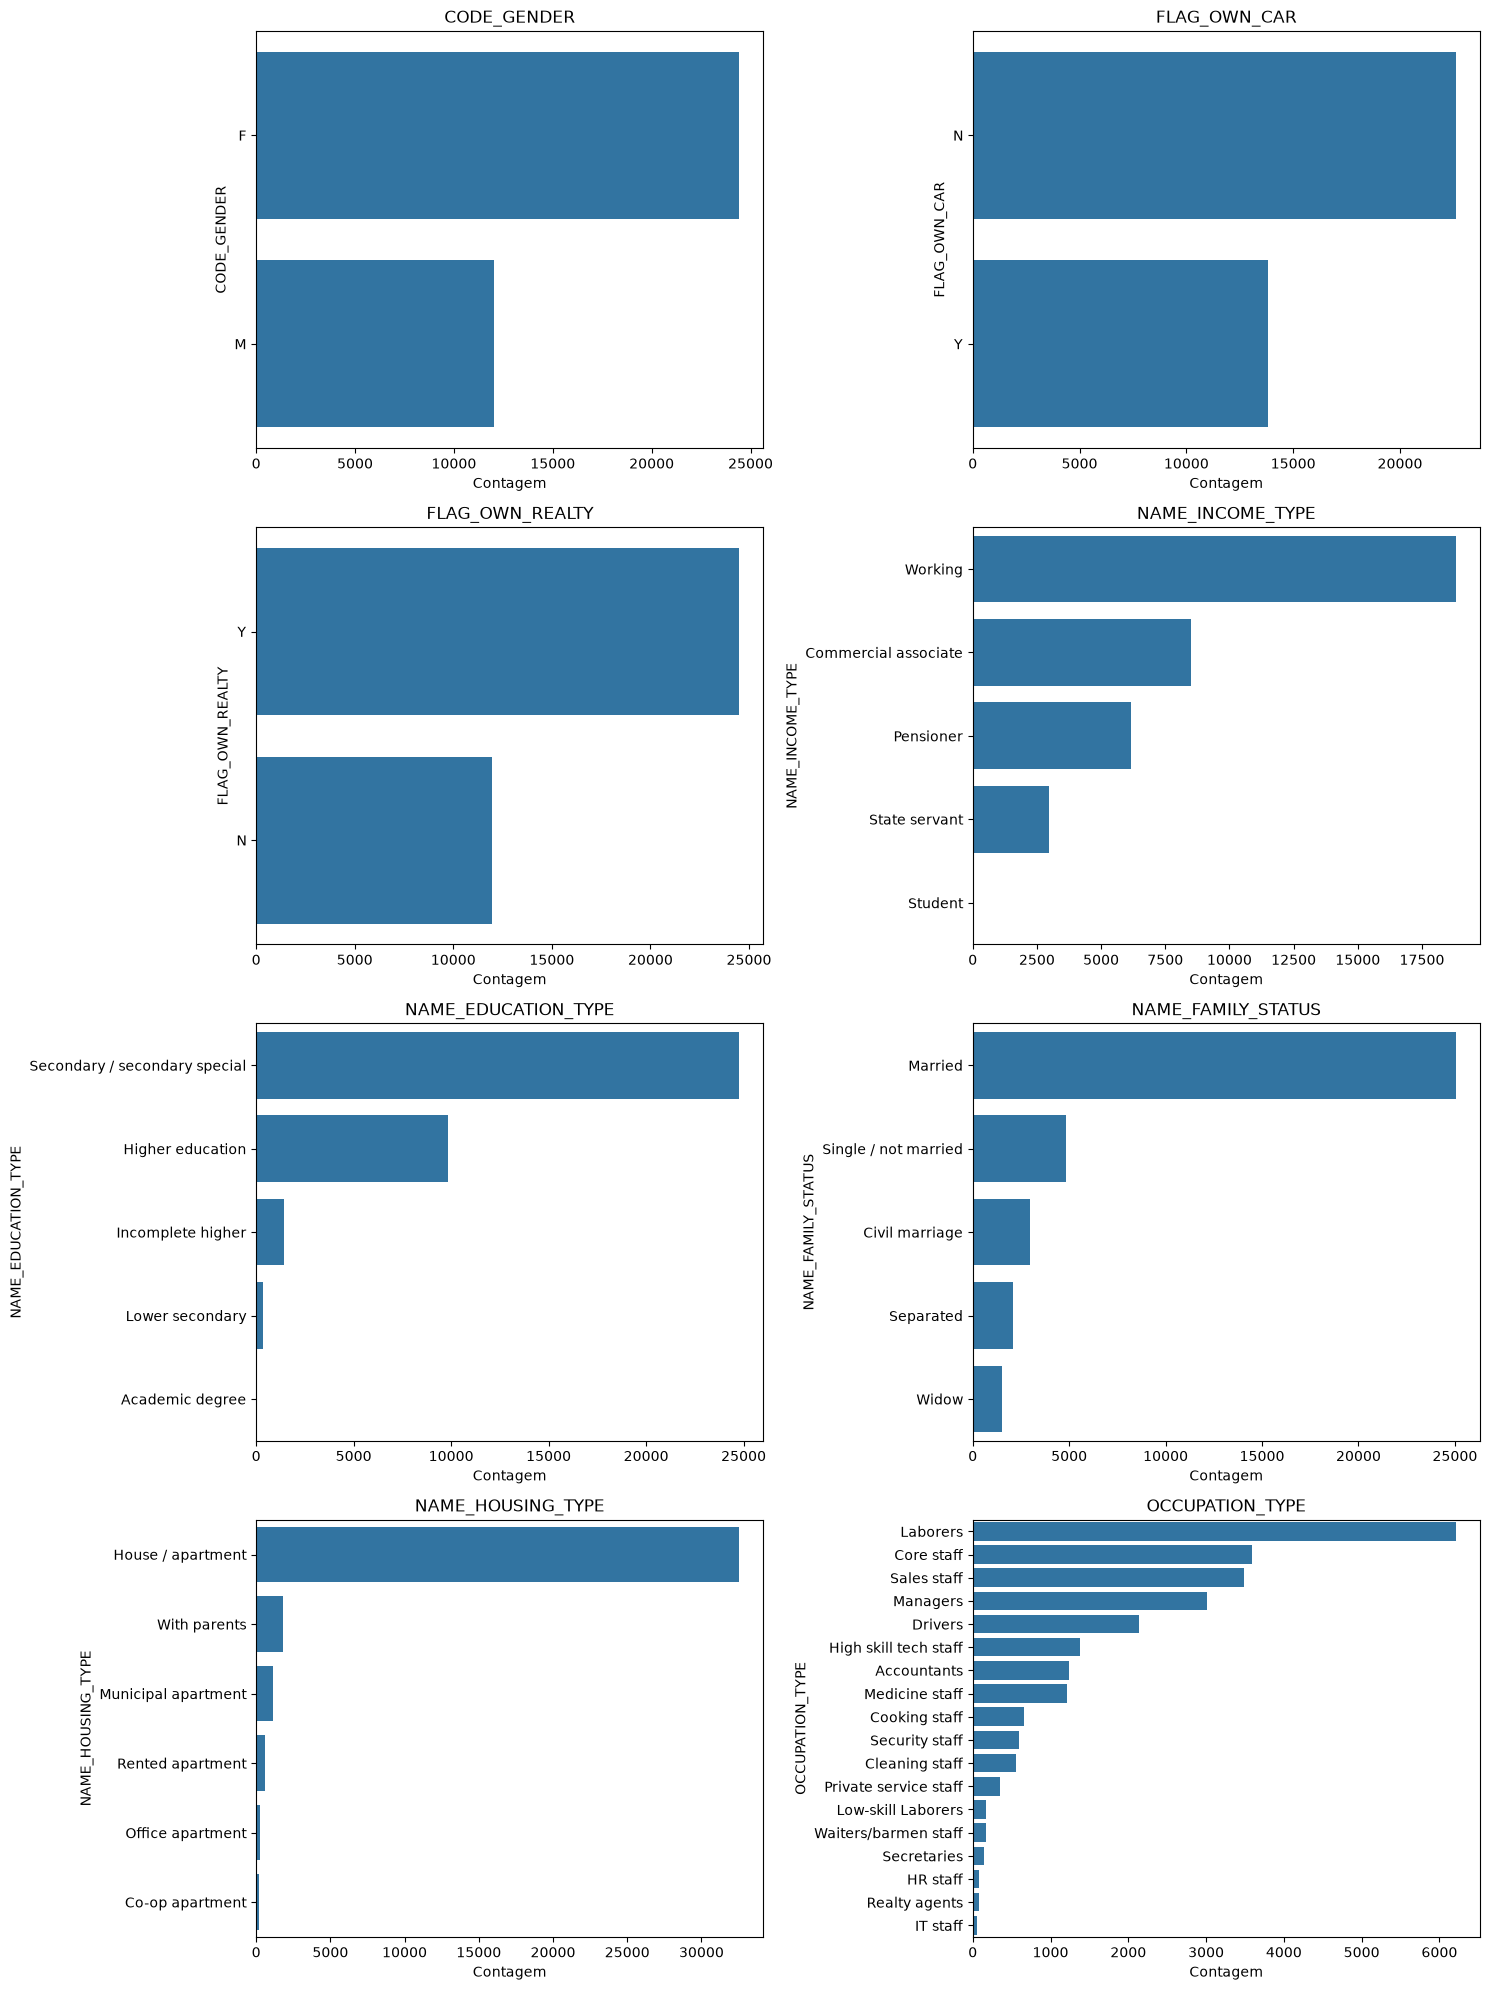

In [32]:
cat_cols = ["CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY", "NAME_INCOME_TYPE",
            "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE",
            "OCCUPATION_TYPE"]

fig, ax = plt.subplots(4, 2, figsize=(15, 20))

for eixo, cat in zip(ax.flat, cat_cols):
    ordem = base[cat].value_counts().index #ordenando pela categoria mais frequente
    sns.countplot(
        y=base[cat],
        order= ordem,
        ax=eixo)

    eixo.set_title(cat)
    eixo.set_xlabel("Contagem")
    eixo.set_ylabel(cat)

plt.tight_layout()
plt.show()

O perfil típico da base é composto por **mulheres** **casadas**, morando em **casa/apartamento** próprio, em sua maioria com **ensino médio** e **assalariadas**, que possuem imóvel, mas não carro próprio. Por fim, a coluna **OCCUPATION_TYPE** mostra-se a variável mais pulverizada (18 categorias no total), com destaque para os tipos de ocupação: Laborers, Core staff e Sales staff.

# **3. Correlações**

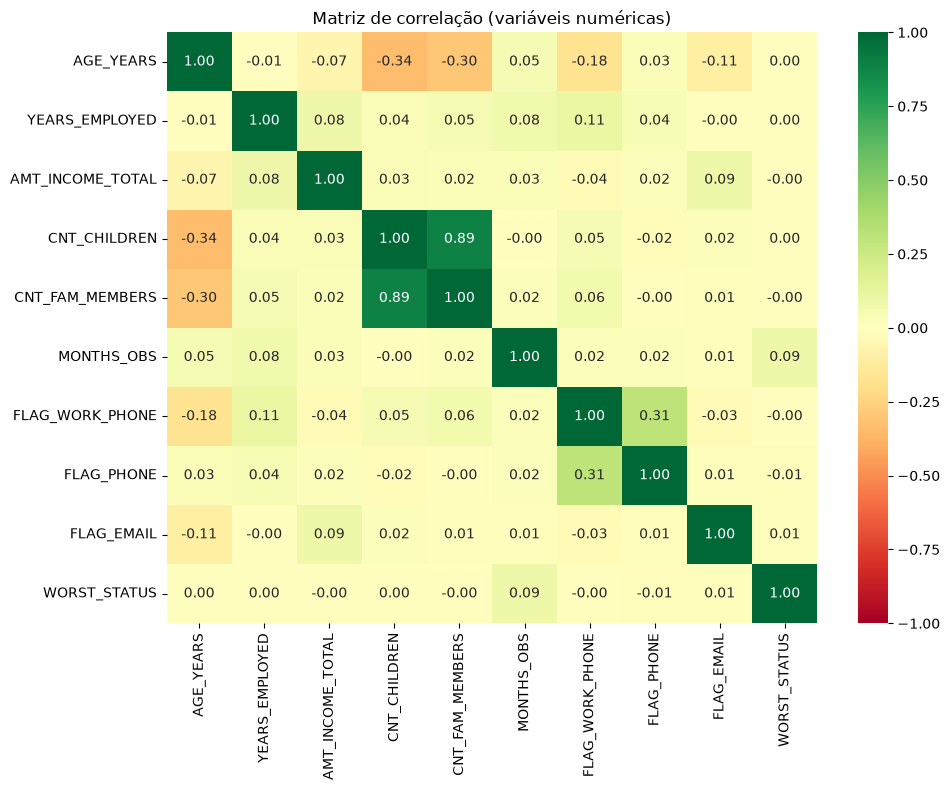

WORST_STATUS        1.000000
MONTHS_OBS          0.090001
FLAG_EMAIL          0.014221
CNT_CHILDREN        0.001160
YEARS_EMPLOYED      0.000510
AGE_YEARS           0.000182
AMT_INCOME_TOTAL   -0.002930
CNT_FAM_MEMBERS    -0.003400
FLAG_WORK_PHONE    -0.004244
FLAG_PHONE         -0.008408
Name: WORST_STATUS, dtype: float64

In [33]:
corr_cols = ["AGE_YEARS", "YEARS_EMPLOYED", "AMT_INCOME_TOTAL", "CNT_CHILDREN",
             "CNT_FAM_MEMBERS", "MONTHS_OBS", "FLAG_WORK_PHONE", "FLAG_PHONE",
             "FLAG_EMAIL", "WORST_STATUS"]

corr = base[corr_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0, vmin =-1, vmax=1)
plt.title("Matriz de correlação (variáveis numéricas)")
plt.tight_layout()
plt.show()
corr["WORST_STATUS"].sort_values(ascending=False) #verificando a correlação com base no coluna WORST_STATUS

****INTERPRETAÇÃO:****

* ****CN_CHILDREN X CNT_FAM_MEMBERS:**** possuem uma correlação linear muito forte (****0,89****), porém esperada, já que a coluna de quantidade de membros da família (adultos + filhos) carrega a informação da quantidade de filhos. Contudo, isso também resulta em uma possível ****multicolinearidade****, em que essas duas variáveis levam praticamente a mesma informação para o modelo, dificultando modelos, como regressão logística, de separar os efeitos individuais de cada variável. Isso pode produzir coeficientes instáveis, por exemplo: CNT_CHILDREN → coeficiente = +0,82; CNT_FAM_MEMBERS → coeficiente = −0,71. Uma alternativa seria criar a coluna CNT_ADULT (membros − filhos).

* ****AGE_YEARS X CNT_CHILDREN:**** Correlação negativa moderada/fraca (−0,34). É coerente essa relação inversa, pois clientes mais velhos tendem a possuir filhos fora do seu núcleo familiar, ou seja, que já constituíram sua própria família.

* ****FLAG_WORK_PHONE x FLAG_PHONE:**** Existe uma associação positiva entre ter telefone no trabalho e ter telefone na residência (0,31), todavia não são equivalentes e cada uma pode carregar informação própria, não cabendo eliminar uma delas devido a essa correlação.

* ****IDADE_ANOS**** x ****FLAG_WORK_PHONE**** = −0,18 e ****FLAG_EMAIL = −0,11**** possuem uma correlação negativa bem fraca; todavia, pode-se inferir que clientes mais jovens fornecem mais canais digitais de contato.

* ****AMT_INCOME_TOTAL (Renda)**** praticamente não se correlaciona com nada (máximo de 0,09 com tempo de emprego e com e-mail; −0,07 com idade). Ou seja, renda carrega informação própria — não é substituível por outra variável.

* ****PIOR_STATUS (proxy de risco) × todas as demais: no máximo |0,10|.**** Nenhuma variável cadastral se associa linearmente ao comportamento de pagamento.




## **3.1 Risco por variável**

Será analisado o **WORST_STATUS**(pior status) dos clientes por faixa etária e por meses observados.


In [34]:
(base['WORST_STATUS'] >=1).astype(int)

0        1
1        1
2        0
3        0
4        0
        ..
36452    1
36453    1
36454    1
36455    1
36456    1
Name: WORST_STATUS, Length: 36457, dtype: int64

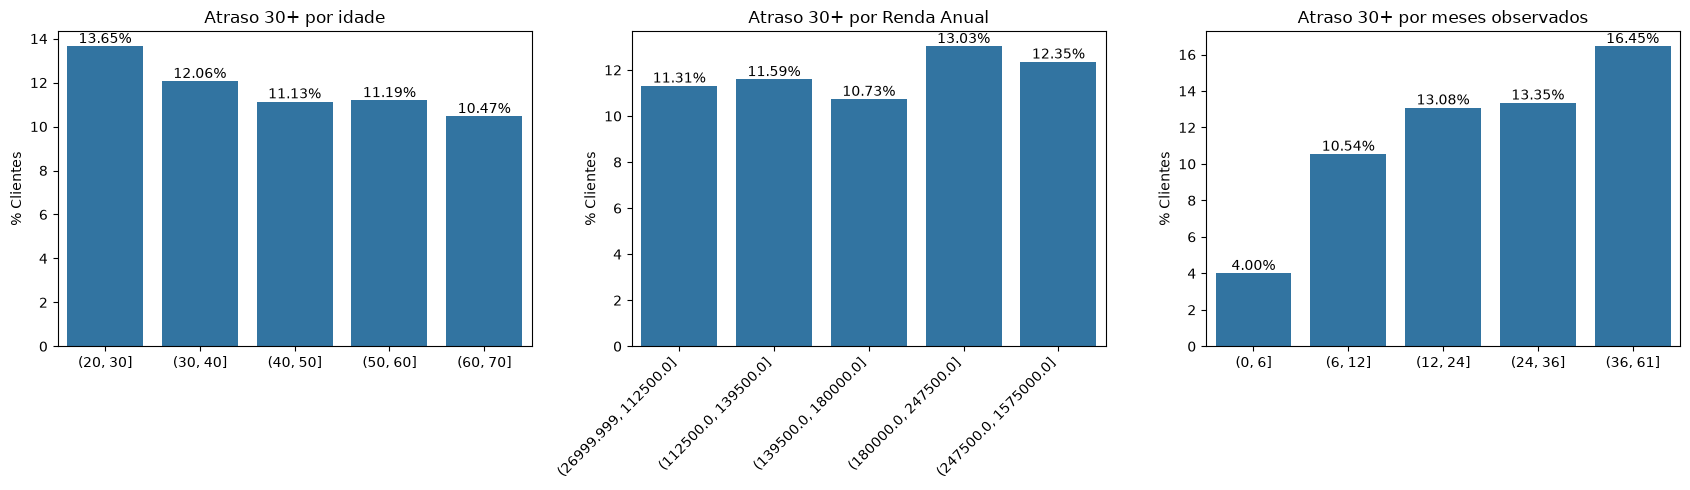

In [35]:
filtro_ws = (base['WORST_STATUS'] >=1).astype(int) #filtra os atrasos de 30 dias em diante. o astype transforma True:1 e False:0

#----------------1. Status x Faixa etária---------------
itv_idade = pd.cut(base['AGE_YEARS'], [20,30,40,50,60,70]) #divide as idades em 5 intervalos

#agrupa os valores do filtro pelos intervalos de idade, tira sua média, multiplica por 100
ay_plot = filtro_ws.groupby(itv_idade, observed=True).mean().mul(100)
fig, ax = plt.subplots(1, 3, figsize= (17,5))

sns.barplot(x = ay_plot.index,
            y = ay_plot.values,
            ax=ax[0])
ax[0].set(title = "Atraso 30+ por idade",
          xlabel = "",
          ylabel = "% Clientes")
for container in ax[0].containers:
    ax[0].bar_label(container, fmt = "%.2f%%",padding = 0)

#--------------------2. Status x Renda Anual------------------------
itv_renda = pd.qcut(base["AMT_INCOME_TOTAL"], 5)

#agrupa os valores do filtro pelos intervalos de idade, tira sua média, multiplica por 100
ait_plot = filtro_ws.groupby(itv_renda, observed=True).mean().mul(100)
sns.barplot(x = ait_plot.index,
            y = ait_plot.values,
            ax=ax[1])
ax[1].set(title = "Atraso 30+ por Renda Anual",
          xlabel = "",
          ylabel = "% Clientes")
#rotaciona e alinha os textos a direita
plt.setp(
    ax[1].get_xticklabels(),
    rotation=45,
    ha="right")
#Insere os valores em cima das barras
for container in ax[1].containers:
    ax[1].bar_label(container, fmt = "%.2f%%",padding = 0)

#--------------------3. Status x Meses Observados------------------------
itv_meses = pd.cut(base['MONTHS_OBS'], [0,6,12,24,36,61])
mo_plot = filtro_ws.groupby(itv_meses, observed=True).mean().mul(100)

sns.barplot(x = mo_plot.index,
            y = mo_plot.values,
            ax = ax[2])
ax[2].set(title = "Atraso 30+ por meses observados",
          xlabel = "",
          ylabel = "% Clientes")
#Insere os valores em cima das barras
for container in ax[2].containers:
    ax[2].bar_label(container, fmt = "%.2f%%", padding = 0)

plt.tight_layout()
plt.show()


**Insights**

* **1) Existe uma leve tendência geral de redução do percentual de clientes com atraso de 30 dias ou mais conforme a idade aumenta.**
* **2) Não existe uma tendência linear clara entre renda e atraso.**
* **3) O insight mais importante! Mesmo que pareça haver uma tendência positiva entre risco e tempo de observação, isso ocorre porque `quanto mais tempo um cliente é observado, maior é a chance de um atraso aparecer em algum mês`. Trata-se de exposição, não de risco. Caso seja incluída no modelo, ele aprenderá uma relação falsa: "se o cliente tem 48 meses de histórico, a probabilidade de ter atrasado é maior". No momento do underwriting (concessão), MESES_OBS é zero ou desconhecido. Incluí-la destruiria a capacidade de generalização do modelo em produção.**

# **4. Outliers**

## 4.1 Identificando a quantidade de outliers nas variáveis numéricas.

In [36]:
col_outliers = ["AMT_INCOME_TOTAL", "AGE_YEARS", "YEARS_EMPLOYED", "CNT_CHILDREN", "CNT_FAM_MEMBERS"]

def resumo_outliers(serie):
    q1, q3 = serie.quantile([0.25, 0.75]) #usando a função quantile para encontrar o quartil superior (q3) e inferior (q1)
    iqr = q3-q1 
    lim_sup = q3 + 1.5*iqr
    lim_inf = q1 - 1.5*iqr
    outliers = (serie < lim_inf) | (serie > lim_sup) #cria um filtro para identificar os outliers das colunas (series)
    return {
        "Limite Superior": round(lim_sup,1),
        "Limite Inferior": round(lim_inf,1),
        "N° Outliers":  int(outliers.sum()),
        "Porcentagem %": round(outliers.mean()*100,2)
    } #retorna em formato de dicionário

In [37]:
#criando um dataframe que armazena o dicionario comprehension das colunas outliers, apos passarem pela função 
pd.DataFrame({
    c: resumo_outliers(base[c])
    for c in col_outliers
    }).T.sort_values(by='Porcentagem %', ascending=False)

,Limite Superior,Limite Inferior,N° Outliers,Porcentagem %
YEARS_EMPLOYED,18.5,-9.5,1997.0,5.48
AMT_INCOME_TOTAL,380250.0,-33750.0,1529.0,4.19
CNT_CHILDREN,2.5,-1.5,508.0,1.39
CNT_FAM_MEMBERS,4.5,0.5,480.0,1.32
AGE_YEARS,81.5,5.5,0.0,0.00


Com a função acima, `resumo_outliers`, foi possível identificar as colunas com a maior porcentagem de outliers: YEARS_EMPLOYED, AMT_INCOME_TOTAL, CNT_CHILDREN. Abaixo o gráfico de cada uma delas.

## 4.2 Plotagem e análises dos boxplots

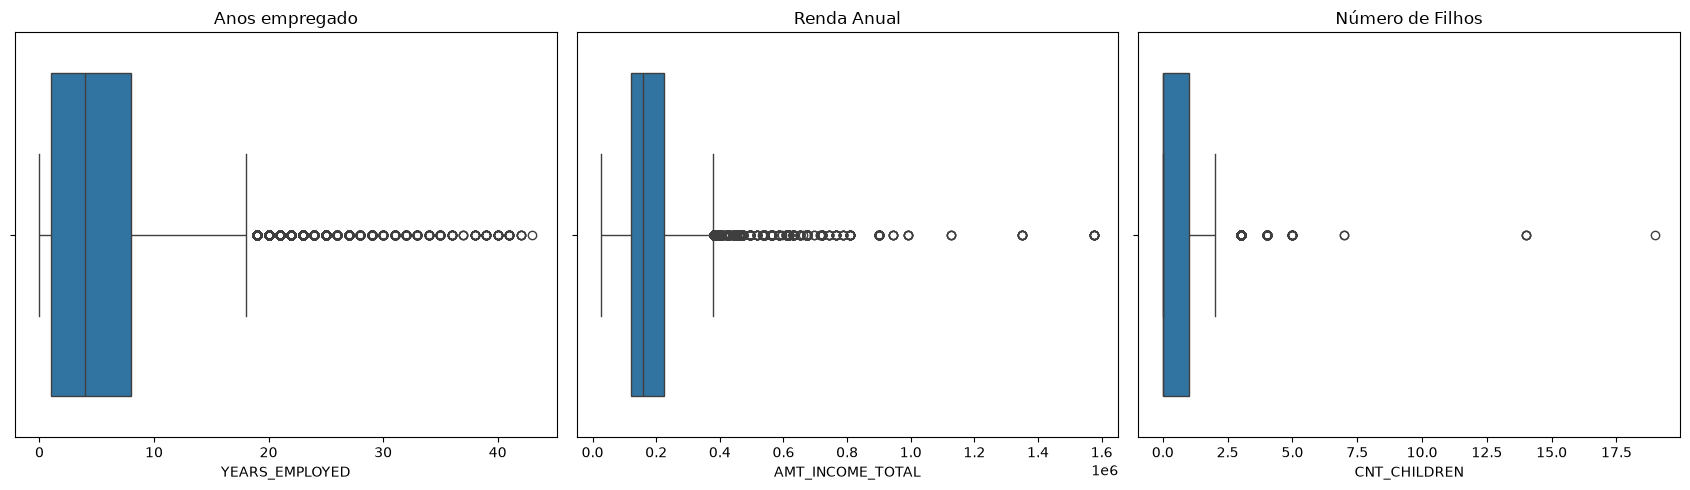

In [38]:
fig, ax = plt.subplots(1,3, figsize = (17,5))

sns.boxplot(x = base['YEARS_EMPLOYED'],
            ax = ax[0])
ax[0].set(title = "Anos empregado")

sns.boxplot(x = base['AMT_INCOME_TOTAL'],
            ax = ax[1])
ax[1].set(title = "Renda Anual")

sns.boxplot(x = base['CNT_CHILDREN'],
            ax = ax[2])
ax[2].set(title = "Número de Filhos")

plt.tight_layout()
plt.show()

**INTERPRETAÇÃO**

* **YEARS_EMPLOYED:** Existem 1.997 observações acima do limite superior (18,5 anos), porém é extremamente factível, pois 43 anos de experiência profissional não se caracterizam como erro. Uma pessoa que começou a trabalhar aos 18 anos e tem 60 anos poderia, por exemplo, possuir mais de 40 anos de experiência. Portanto, será **mantida**.
* **AMT_INCOME_TOTAL:** Como visto anteriormente no gráfico de distribuição e agora no boxplot, a renda anual possui **forte assimetria à direita** e **valores muito altos**. Contudo, como representam uma parcela relevante da amostra, **4,19%**, nesse caso será usada a técnica de **winsorização** no notebook `02-preprocessamento`, de forma que os valores acima do percentil 99 (o 1% mais alto) assumam o valor do percentil 0,99.

In [39]:
base["CNT_CHILDREN"].value_counts().sort_values()

CNT_CHILDREN
19        1
7         2
14        3
5        20
4        63
3       419
2      3256
1      7492
0     25201
Name: count, dtype: int64

In [40]:
base[(base['CNT_CHILDREN'])>(base['CNT_FAM_MEMBERS'])]

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE_YEARS,YEARS_EMPLOYED,WORST_STATUS,MONTHS_OBS,MONTH_BEGAN
36138,5023641,M,Y,N,2,225000.0,Working,Secondary / secondary special,Married,House / apartment,-14776,-2212,1,0,0,0,Drivers,1.0,40,6,2,31,-30
36187,5045457,M,Y,N,2,180000.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-14452,-4249,1,0,0,0,Drivers,1.0,39,11,2,36,-35


* **CNT_CHILDREN:** os valores 14 e 19 aparecem em apenas 1 a 3 registros, destoam completamente do restante da distribuição (que vai de 0 a 5) e são consistentes com erro de cadastro. **Decisão: tratar como erro e não como outlier legítimo** — no notebook 02.preprocessamento esses valores serão capados em um teto mais razoável (ex.: 5), preservando a linha em vez de descartar o cliente inteiro.

# **5. Balanceamento de Classes**

A coluna ` WORST_STATUS` será utilizada no balancemento de classes e, posteriormente, no notebook 02.preprocessamento para criação da variável **TARGET**

In [41]:
ws_plot = base['WORST_STATUS'].value_counts(normalize=True).mul(100).round(2).sort_index(ascending=False)#contando a quantidade de cada status e tornando em porcentagem por meio do normalize
ws_plot.rename ({-2: "X (Sem contrato)", #renomeando os indices para melhore legibilidade no grafico
                 -1: "C (Quitado)",
                 0: "0 (até 29 dias)",
                 1: "1 (30–59 dias)",
                 2: "2 (60–89 dias)",
                 3: "3 (90–119 dias)",
                 4: "4 (120–149 dias)",
                 5: "5 (150+ dias)"}, inplace=True)

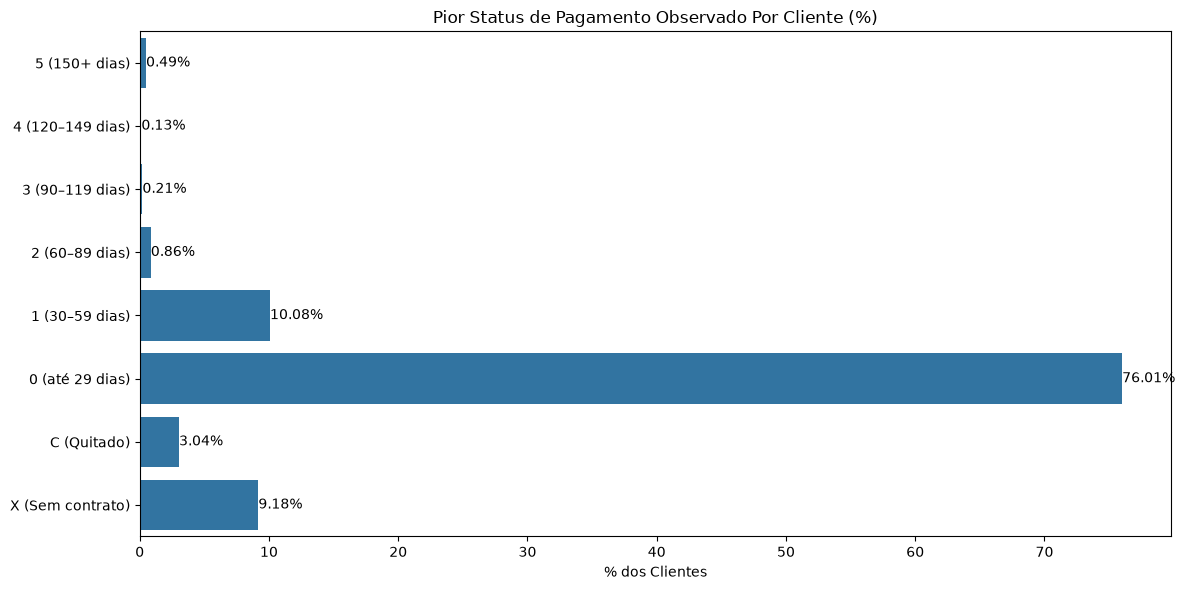

In [42]:
fig, ax = plt.subplots(figsize = (12,6))

sns.barplot(y=ws_plot.index.astype(str),
            x=ws_plot.values,
            ax = ax)
ax.set(title = "Pior Status de Pagamento Observado Por Cliente (%)",
       ylabel = "",
       xlabel = "% dos Clientes")

ax.bar_label(ax.containers[0], padding=0, fmt="%.2f%%")

plt.tight_layout()
plt.show()


In [43]:
range_atraso = [1,2,3,4,5]
pd.DataFrame(
    {"Critério": f"Pior Status >= {k}",
     "Quantidade":(base['WORST_STATUS']>=k).sum(),
     "Porcentagem": f"{round((base['WORST_STATUS']>=k).mean()*100,2)} %"}
    for k in range_atraso
    )

,Critério,Quantidade,Porcentagem
0,Pior Status >= 1,4291,11.77 %
1,Pior Status >= 2,616,1.69 %
2,Pior Status >= 3,302,0.83 %
3,Pior Status >= 4,226,0.62 %
4,Pior Status >= 5,180,0.49 %


**INTERPRETAÇÃO**
A base apresenta um forte desbalanceamento: a grande maioria dos clientes (~88,23%) nunca teve atrasos iguais ou superiores a 30 dias (Status 0/C), tornando a amostra de inadimplentes reduzida.

Optou-se por seguir o padrão consolidado de mercado e adotar o limiar de 60+ dias para caracterizar o cliente como "mau pagador". Embora a escolha de um limiar de 30+ dias resultasse em um dataset menos desbalanceado, ela correria o risco de classificar como maus pagadores clientes com atrasos meramente pontuais ou operacionais, mas que possuem bom perfil de crédito.

## 5.1 Duplicidade de Perfil

Identificamos que diversas linhas possuíam o perfil de cliente idêntico, ou seja, todas as demais são linhas iguais a exceção do seu ID.

In [44]:
no_id = dados_pessoais.copy()
no_id = no_id.drop(columns = 'ID') #criando um dataframe sem a coluna ID

perfil_duplicado = base.duplicated(no_id.columns).sum() #quantidade de linhas com perfil duplicado
perfis_distintos = base.drop_duplicates(subset=no_id.columns).shape[0] #linhas após remoção dos duplicados

print(f"Linhas com perfil idêntico a outra: {perfil_duplicado} ({perfil_duplicado/len(base)*100:.1f}%)")
print(f"Perfis distinto: {perfis_distintos}")




Linhas com perfil idêntico a outra: 26729 (73.3%)
Perfis distinto: 9728


Dos 36.457 clientes, **26.729 (73,3%) repetem exatamente o mesmo vetor de atributos de outro cliente** — restam apenas **9.728 perfis distintos**. Como os IDs são diferentes e os históricos também, cada perfil aparece várias vezes com rótulos que podem divergir.

O risco é concreto: em um split aleatório, cópias do mesmo vetor caem em treino e teste, e o modelo "acerta" por memorização, inflando as métricas. Além disso, perfis idênticos com desfechos opostos representam ruído irredutível — são o limite superior do que qualquer modelo pode acertar. O tratamento é decidido e justificado no notebook 02.

# **6. Síntese da EDA**

**1. O universo modelável é bem menor do que parece.** Das 438.557 solicitações, apenas **36.457 (8,3%)** têm histórico de pagamento e podem ser rotuladas. Como o objetivo é treinar o modelo para que aprenda a prever bons ou maus pagadores, é imprescindível que haja histórico de crédito.

**2. O alvo não vem pronto:** O histórico traz status mensais, não um rótulo. A inadimplência de 60+ dias é a definição de mercado, mas rende apenas 1,69% de positivos.

**3. O sinal correlacional é fraco:** Nenhuma das variáveis cadastrais apresenta correlação superior a |0,10| com o comportamento de pagamento, indicando uma relação linear muito fraca entre essas características e a ocorrência de atraso. Entre as diferentes faixas etárias, a taxa de atraso varia de **10,47% a 13,65%**, sem diferenças suficientemente expressivas para indicar uma relação clara. Da mesma forma, a análise da renda não evidencia uma tendência consistente de aumento ou redução da taxa de atraso à medida que a renda varia.


**4. Os dados escondiam algumas armadilhas:** `DAYS_EMPLOYED = 365243` para 75.329 aposentados, `FLAG_MOBIL` constante e 2 famílias com mais filhos do que membros. Nenhum deles é facilmente percebido e eles poderiam degradar o modelo.